In [38]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("merged_audio_features.csv")

# Identify the column that contains class labels (you may need to adjust this if the column name is different)
# Let's assume the column name is 'label'
class_column = 'label'  # Modify this if the actual column name is different

# Split the dataset into training and testing while maintaining 75% for training and 25% for testing
train_data = []
test_data = []

# Split by class label to ensure 75% of each class goes into the training set
for label in df[class_column].unique():
    # Filter data for this specific label
    class_data = df[df[class_column] == label]
    
    # Split the class data (75% for training and 25% for testing)
    train_class, test_class = train_test_split(class_data, test_size=0.25, random_state=42)
    
    # Append to the respective lists
    train_data.append(train_class)
    test_data.append(test_class)

# Concatenate the training and testing data
train_df = pd.concat(train_data)
test_df = pd.concat(test_data)

# Shuffle the data (optional but recommended for randomness)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV files
train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print("Data has been successfully split and saved into 'train_data.csv' and 'test_data.csv'.")


Data has been successfully split and saved into 'train_data.csv' and 'test_data.csv'.


In [40]:
class SpeechFeatureDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

        # Encode string labels into integers
        self.label_encoder = LabelEncoder()
        self.df['label'] = self.label_encoder.fit_transform(self.df['label'])

        # Store the label mapping
        self.label_map = dict(zip(self.label_encoder.classes_, self.label_encoder.transform(self.label_encoder.classes_)))

        # Extract labels
        self.labels = self.df['label'].values.astype(int)

        # Extract features and normalize
        self.feature_df = self.df.drop(columns=['file_name', 'label'])
        self.feature_names = self.feature_df.columns.tolist()
        self.feature_df = (self.feature_df - self.feature_df.mean()) / (self.feature_df.std() + 1e-8)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        features = self.feature_df.iloc[idx].values.astype(np.float32)
        label = self.labels[idx]
        return torch.tensor(features), torch.tensor(label, dtype=torch.long)


In [41]:
# CNN-LSTM-RNN Model
class CNN_LSTM_RNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(CNN_LSTM_RNN, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=1, batch_first=True)
        self.rnn = nn.RNN(input_size=128, hidden_size=64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, features)
        x = self.cnn(x)     # (batch, channels, features)
        x = x.permute(0, 2, 1)  # (batch, sequence_len, features)
        x, _ = self.lstm(x)
        x, _ = self.rnn(x)
        x = x[:, -1, :]  # Last time step
        out = self.fc(x)
        return out

In [42]:
# Training function
def train_model(model, dataloader, criterion, optimizer, device, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for features, labels in dataloader:
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataloader):.4f}")


In [43]:
# Main execution
if __name__ == "__main__":
    
    batch_size = 32
    num_epochs = 20
    learning_rate = 0.001

    csv_path = r"train_data.csv" 
    csv_path1 = r"test_data.csv" 
    dataset = SpeechFeatureDataset(csv_path)
    dataset1 = SpeechFeatureDataset(csv_path1)

    num_classes = len(dataset.label_map)

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    dataloader1 = DataLoader(dataset1, batch_size=batch_size, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    input_dim = dataset[0][0].shape[0]

    model = CNN_LSTM_RNN(input_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_model(model, dataloader, criterion, optimizer, device, num_epochs)


Epoch [1/20], Loss: 0.5641
Epoch [2/20], Loss: 0.4250
Epoch [3/20], Loss: 0.3126
Epoch [4/20], Loss: 0.2449
Epoch [5/20], Loss: 0.2093
Epoch [6/20], Loss: 0.1869
Epoch [7/20], Loss: 0.1716
Epoch [8/20], Loss: 0.1577
Epoch [9/20], Loss: 0.1445
Epoch [10/20], Loss: 0.1286
Epoch [11/20], Loss: 0.1244
Epoch [12/20], Loss: 0.1126
Epoch [13/20], Loss: 0.1023
Epoch [14/20], Loss: 0.0987
Epoch [15/20], Loss: 0.0873
Epoch [16/20], Loss: 0.0803
Epoch [17/20], Loss: 0.0714
Epoch [18/20], Loss: 0.0640
Epoch [19/20], Loss: 0.0599
Epoch [20/20], Loss: 0.0561


In [44]:
print(dataset.label_map)  # Example: {'healthy': 0, 'impaired': 1, 'severe': 2}

{'dysarthria': 0, 'healthy': 1, 'hyperkinetic dysphonia': 2, 'hypokinetic dysphonia': 3, 'reflux laryngitis': 4}


In [45]:
print(dataset1.label_map)  # Example: {'healthy': 0, 'impaired': 1, 'severe': 2}

{'dysarthria': 0, 'healthy': 1, 'hyperkinetic dysphonia': 2, 'hypokinetic dysphonia': 3, 'reflux laryngitis': 4}


In [46]:
dataset.df.shape

(15404, 326)

In [47]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def test_model(model, test_loader, device, label_encoder):
    model.eval()  # Set the model to evaluation mode (important!)
    all_preds = []
    all_labels = []

    with torch.no_grad():  # No gradient tracking during testing
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)  # Get predicted class
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Decode numeric predictions back to label names (optional)
    all_preds_decoded = label_encoder.inverse_transform(all_preds)
    all_labels_decoded = label_encoder.inverse_transform(all_labels)

    # Print performance
    print("Classification Report:")
    print(classification_report(all_labels_decoded, all_preds_decoded))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels_decoded, all_preds_decoded))

    

    sns.heatmap(confusion_matrix(all_labels_decoded, all_preds_decoded), annot=True, fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Classification Report:
                        precision    recall  f1-score   support

            dysarthria       0.95      0.96      0.95      2864
               healthy       0.93      0.93      0.93      2234
hyperkinetic dysphonia       0.29      0.22      0.25        18
 hypokinetic dysphonia       0.50      0.09      0.15        11
     reflux laryngitis       0.00      0.00      0.00        10

              accuracy                           0.94      5137
             macro avg       0.53      0.44      0.46      5137
          weighted avg       0.94      0.94      0.94      5137

Confusion Matrix:
[[2741  123    0    0    0]
 [ 158 2074    2    0    0]
 [   0   13    4    1    0]
 [   0    3    7    1    0]
 [   0    9    1    0    0]]


c:\Users\rishi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rishi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rishi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

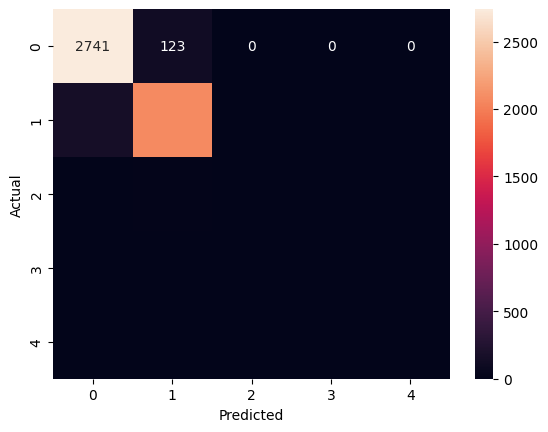

In [48]:
test_model(model, dataloader1, device, dataset1.label_encoder)
